## Analyze A/B Test Results


## Table of Contents
- [Introduction](#intro)
- [Part I - Probability](#probability)
- [Part II - A/B Test](#ab_test)


<a id='intro'></a>
### Introduction

A/B tests are very commonly performed by data analysts and data scientists.

For this project, I will be working to understand the results of an A/B test run by an e-commerce website.  My goal is to work through this notebook to help the company understand if they should implement the new page, keep the old page, or perhaps run the experiment longer to make their decision.


<a id='probability'></a>
#### Part I - Probability

To get started, let's import our libraries.

In [2]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import scipy
from scipy import stats

%matplotlib inline
#We are setting the seed to assure you get the same answers on quizzes as we set up
random.seed(42)

`1.` Now, read in the `ab_data.csv` data. Store it in `df`.

a. Read in the dataset and take a look at the top few rows here:

In [4]:
#import the dataset
df = pd.read_csv('/content/Analyze-A-B-Results-master_ab_data.csv')

#show the first 5 rows
df.head()

,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


b. Use the below cell to find the number of rows in the dataset.

In [5]:
#show the total number of rows
df.shape[0]

294478

c. The number of unique users in the dataset.

In [6]:
#calculare the number of unique user_id
len(df['user_id'].unique())

290584

d. The proportion of users converted.

In [7]:
#calculate the converted users
df['converted'].mean()

np.float64(0.11965919355605512)

e. The number of times the `new_page` and `treatment` don't line up.

In [8]:
#treatment in group will be called A and new_page in landing_page will
#be called B

df_A_not_B = df.query('group == "treatment" & landing_page != "new_page"')

df_B_not_A = df.query('group != "treatment" & landing_page == "new_page"')

#calculate thenumber of time new_page and treatment don't line up
len(df_A_not_B) + len(df_B_not_A)

3893

f. Do any of the rows have missing values?

In [9]:
#view if there is any missing value
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   user_id       294478 non-null  int64 
 1   timestamp     294478 non-null  object
 2   group         294478 non-null  object
 3   landing_page  294478 non-null  object
 4   converted     294478 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.2+ MB


`2.` For the rows where **treatment** is not aligned with **new_page** or **control** is not aligned with **old_page**, we cannot be sure if this row truly received the new or old page.  
a.   Store your new dataframe in **df2**.

In [30]:
#remove the mismatch rows
df1 = df.drop(df[(df.group =="treatment") & (df.landing_page != "new_page")].index)

df2 = df1.drop(df1[(df1.group =="control") & (df1.landing_page != "old_page")].index)


In [29]:
# Double Check all of the correct rows were removed - this should be 0
df2[((df2['group'] == 'treatment') == (df2['landing_page'] == 'new_page')) == False].shape[0]

0

`3.` Use **df2** and the cells below to answer :

a. How many unique **user_id**s are in **df2**?

In [14]:
#calculare the number of unique user_id
len(df2['user_id'].unique())

290584

b. There is one **user_id** repeated in **df2**.  What is it?

In [31]:
#find out the duplicate user_id
df2[df2.duplicated(['user_id'], keep=False)]

,user_id,timestamp,group,landing_page,converted
1899,773192,2017-01-09 05:37:58.781806,treatment,new_page,0
2893,773192,2017-01-14 02:55:59.590927,treatment,new_page,0


c. What is the row information for the repeat **user_id**?

In [16]:
#information found above, rows 1899 and 2893

d. Remove **one** of the rows with a duplicate **user_id**, but keep your dataframe as **df2**.

In [17]:
#remove one of the duplicated rows
df2.drop(labels=2893, inplace=True)

In [18]:
#verify if number of rows have been drop by one
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 290584 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   user_id       290584 non-null  int64 
 1   timestamp     290584 non-null  object
 2   group         290584 non-null  object
 3   landing_page  290584 non-null  object
 4   converted     290584 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 13.3+ MB


`4.` Use **df2** in the below cells.

a. What is the probability of an individual converting regardless of the page they receive?

In [19]:
#calculate the averga of the converted column
df2['converted'].mean()

np.float64(0.11959708724499628)

b. Given that an individual was in the `control` group, what is the probability they converted?

In [32]:
df2.groupby('group')['converted'].mean()


,converted
group,
control,0.120386
treatment,0.118807


c. Given that an individual was in the `treatment` group, what is the probability they converted?

In [33]:
#as above
df2.groupby(['group'],as_index=False)['converted'].mean()

,group,converted
0,control,0.120386
1,treatment,0.118807


d. What is the probability that an individual received the new page?

In [34]:
#retrieve the new_page values and compared with the total number of landing_page
#in order to obtain the probability that an individual that received the
#new_page was converted

len(df2.query('landing_page == "new_page"'))/len(df2.landing_page)

0.5000636646764286

e. Explain below whether there is sufficient evidence to say that the new treatment page leads to more conversions.

No, there is not sufficient evidence to say that the new treatment page leads to more conversions.

The test seems to be well designed. Half of the population received the old_page and half of the population received the new_page. The population is considerable in size (290584 users).

12.04% that received the old_page were converted. 11.88% that received the new_page were converted. In conclusion, the new_page did not increase the conversion rate.

<a id='ab_test'></a>
### Part II - A/B Test

These questions are the difficult parts associated with A/B tests in general.  


`1.` For now, consider a need to make the decision just based on all the data provided.  Assume that the old page is better unless the new page proves to be definitely better at a Type I error rate of 5%, what should null and alternative hypotheses be?  

- Null hypothesis: the conversion rate of the old_page is greater or the same than the conversion rate of the new_page.**$p_{old}$** >= **$p_{new}$**


- Alternative hypothesis: the conversion rate of the old_page is less than the conversion rate of the new_page.
    **$p_{old}$** < **$p_{new}$**

`2.` Assume under the null hypothesis, $p_{new}$ and $p_{old}$ both have "true" success rates equal to the **converted** success rate regardless of page - that is $p_{new}$ and $p_{old}$ are equal. Furthermore, assume they are equal to the **converted** rate in **ab_data.csv** regardless of the page. <br><br>

Performing a sampling distribution for the difference in **converted** between the two pages over 10,000 iterations of calculating an estimate from the null.  <br><br>

a. What is the **convert rate** for $p_{new}$ under the null?

In [35]:
#the Null hypothesis states there is not difference between the
#conversion rates of old and new page. Thus, the whole dataset is used to
#calculate the convertion rate for the new page (pnew).
p_new = df2['converted'].mean()
p_new

np.float64(0.11959667567149027)

b. What is the **convert rate** for $p_{old}$ under the null? <br><br>

In [36]:
#the Null hypothesis states there is not difference between the
#conversion rates of old and new page. Thus, the whole dataset is used to
#calculate the convertion rate for the old_page (pold).
p_old = df2['converted'].mean()
p_old

np.float64(0.11959667567149027)

c. What is $n_{new}$?

In [37]:
#calculate the number of users landed and new_page
n_new = len(df2.query('landing_page == "new_page"'))

n_new

145311

d. What is $n_{old}$?

In [38]:
#calculate the number of users landed and new_page
n_old = len(df2.query('landing_page != "new_page"'))
n_old

145274

e. Simulate $n_{new}$ transactions with a convert rate of $p_{new}$ under the null.  Store these $n_{new}$ 1's and 0's in **new_page_converted**.

In [39]:

new_page_converted = np.random.binomial(1,p_new,n_new)

#new_page_converted = np.random.choice([1, 0], size=n_new, p=[p_new, (1-p_new)])
new_page_converted.mean()

np.float64(0.11919951001644748)

f. Simulate $n_{old}$ transactions with a convert rate of $p_{old}$ under the null.  Store these $n_{old}$ 1's and 0's in **old_page_converted**.

In [40]:
old_page_converted = np.random.binomial(1,p_old,n_old)

#old_page_converted = np.random.choice([1, 0], size=n_old, p=[p_old, (1-p_old)])
old_page_converted.mean()

np.float64(0.11995952476010849)

g. Find $p_{new}$ - $p_{old}$ for your simulated values from part (e) and (f).

In [41]:
#since new_page_converted and old_page_converted have different sizes,
#I use the mean to get the difference
new_page_converted.mean() - old_page_converted.mean()

np.float64(-0.0007600147436610111)

h. Simulate 10,000 $p_{new}$ - $p_{old}$ values using this same process similarly to the one you calculated in parts **a. through g.** above.  Store all 10,000 values in a numpy array called **p_diffs**.

In [42]:
# run simulation 10000 times
p_diffs = []

for _ in range(10000):
    new_page_converted = np.random.binomial(1,p_new,n_new).mean()
    old_page_converted = np.random.binomial(1,p_old,n_old).mean()
    p_diffs.append(new_page_converted - old_page_converted)


i. Plot a histogram of the **p_diffs**.

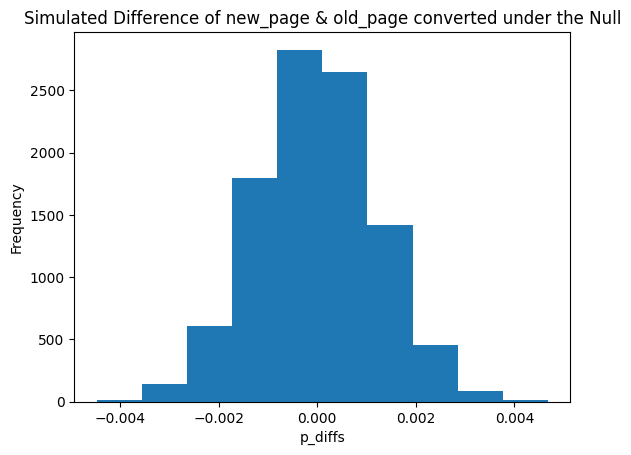

In [43]:
# convert to numpy array
p_diffs = np.array(p_diffs)

# plot sampling distribution
plt.hist(p_diffs)
plt.xlabel('p_diffs')
plt.ylabel('Frequency')
plt.title('Simulated Difference of new_page & old_page converted under the Null');

j. What proportion of the **p_diffs** are greater than the actual difference observed in **ab_data.csv**?

In [44]:
df_control = df2.query('group == "control"')
df_treatment = df2.query('group == "treatment"')

# display observed difference
obs_diff = df_treatment.converted.mean() - df_control.converted.mean()
obs_diff

np.float64(-0.0015790565976871451)

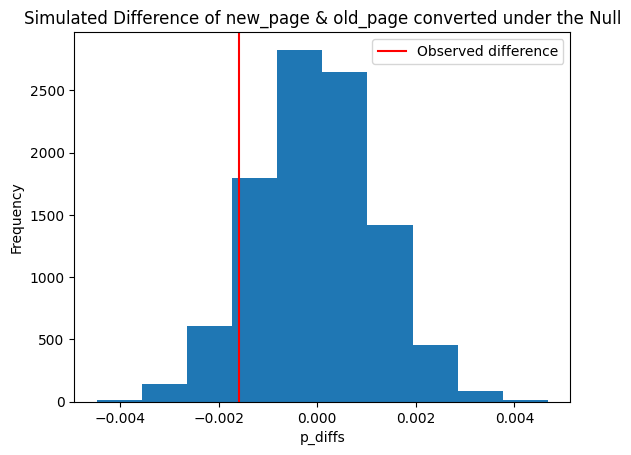

In [45]:
# plot line for observed statistic
plt.hist(p_diffs)
plt.axvline(x=obs_diff, color='r', label="Observed difference")
plt.xlabel('p_diffs')
plt.ylabel('Frequency')
plt.title('Simulated Difference of new_page & old_page converted under the Null');
plt.legend()
plt.show()

In [46]:
#calculate the proportion of p_diffs greater than the observe difference
(p_diffs > obs_diff).mean()

np.float64(0.9044)

90.44% is the proportion of the p_diffs that are greater than the actual difference observed in ab_data.csv.

90.44% is the proportion of the p_diffs that are greater than the actual difference observed in ab_data.csv. In scientific studies this value is also called p-value. This value means that we cannot reject the null hypothesis and that we do not have sufficient evidence that the new_page has a higher conversion rate than the old_page.

l. We could also use a built-in to achieve similar results.  Though using the built-in might be easier to code, the above portions are a walkthrough of the ideas that are critical to correctly thinking about statistical significance. Fill in the below to calculate the number of conversions for each page, as well as the number of individuals who received each page. Let `n_old` and `n_new` refer the the number of rows associated with the old page and new pages, respectively.

In [48]:
import statsmodels.api as sm

n_new = len(df2.query('landing_page == "new_page"'))
n_old = len(df2.query('landing_page == "old_page"'))
convert_new = len(df2.query('landing_page == "new_page" & converted == 1'))
convert_old = len(df2.query('landing_page == "old_page" & converted == 1'))


In [49]:
convert_new, convert_old

(17264, 17489)

In [50]:
n_new, n_old

(145311, 145274)

m. Now use `stats.proportions_ztest` to compute your test statistic and p-value.

In [51]:
z_score, p_value = sm.stats.proportions_ztest([convert_old, convert_new], [n_old, n_new],value=None, alternative='smaller', prop_var=False)

z_score, p_value

(np.float64(1.3116075339133115), np.float64(0.905173705140591))

The z-score and the p_value mean that one doesn't reject the Null. The Null being the converted rate of the old_page is the same or greater than the converted rate of the new_page. The p_value is 0.91 and is higher than 0.05 significance level. That means we can not be confident with a 95% confidence level that the converted rate of the new_page is  larger than the old_page.

<a id='conclusions'></a>
## Conclusions

In conclusion, there is not enough evidence that the new_page increases the conversion rate as compared to the old_page. This is based on the probability figures, A/B testand regression. There is no strong evidence that the countries (US, CA and UK) influence the conversion rate.

Since the sample size is large continuing the testing of the new_page is likely not necessary. It is best to focus on the development of another new landing page.

